## What you must hand in
- Marked spectrum with the starts/ends and most intense lines of each progression ($v''=0,1,2$).
- Clean table for $v''=0$: peak #, $\lambda$ (nm), $\tilde{\nu}$ ($\text{cm}^{-1}$), $v'$, and $x=v'+\tfrac12$.
- Plot of $\tilde{\nu}$ vs. $x$ with the quadratic fit and fitted coefficients (with units).
- Extracted excited-state constants: $\tilde{\nu}_e'$, $x_e'$, $v_\mathrm{max}'$, $\tilde D_e'$, $\tilde D_0'$, $k_f'$, and $a'$.
- Short comparison of your dissociation energy estimate to a ground-state literature value (and why they differ).

## Inputs
Fill all values before running anything below. Use the assigned peaks for the $v''=0$ progression only. If you have a CSV like `/Users/xiaodong/Desktop/BKinD/KZ4020/UV-VIS_raw_data.csv` with a first line label (e.g., `sample1`) and a header row containing `Wavelength (nm)` and `Abs`, the import in the first code cell will skip the first line, rename `Wavelength (nm)`→`lambda_nm`, and load the data. You still need a `vprime` column in the CSV (or fill `vprime` manually).

In [14]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# 0) Optional: load from CSV (overrides manual entries)
# -----------------------------
csv_path = "UV-VIS_raw_data.csv"  # update if located elsewhere
lambda_nm = []
vprime = []
try:
    df_raw = pd.read_csv(csv_path, comment="#")
    # Drop unnamed trailing columns from extra commas
    df_raw = df_raw.loc[:, ~df_raw.columns.str.contains('^Unnamed')]
    # If the first row looks like a sample label (non-numeric wavelength), drop it
    if df_raw.shape[0] > 0:
        first_val = df_raw.iloc[0, 0]
        first_num = pd.to_numeric(first_val, errors='coerce')
        if pd.isna(first_num):
            df_raw = df_raw.iloc[1:]

    def _norm(name: str) -> str:
        return name.strip().lower().replace(' ', '').replace('(', '').replace(')', '').replace('_', '')

    rename_map = {}
    for col in df_raw.columns:
        n = _norm(col)
        if n in {"lambda", "lambdanm", "wavelengthnm"} or "wavelength" in n:
            rename_map[col] = "lambda_nm"
        elif n in {"vprime", "v'", "vp"}:
            rename_map[col] = "vprime"
        elif n in {"abs", "absorbance", "intensity"}:
            rename_map[col] = "abs"
    if rename_map:
        df_raw = df_raw.rename(columns=rename_map)

    if "lambda_nm" not in df_raw.columns:
        raise ValueError("CSV missing wavelength column (expected header like 'lambda_nm' or 'Wavelength (nm)').")

    # Keep only rows with numeric wavelengths
    lambda_series = pd.to_numeric(df_raw["lambda_nm"], errors="coerce")
    df_raw = df_raw[lambda_series.notna()]
    lambda_nm = df_raw["lambda_nm"].to_numpy(dtype=float)

    if "vprime" in df_raw.columns:
        vprime_series = pd.to_numeric(df_raw["vprime"], errors="coerce")
        if vprime_series.isna().any():
            raise ValueError("vprime column contains non-numeric values; clean or fill manually.")
        vprime = vprime_series.to_numpy(dtype=int)
    else:
        vprime = np.arange(len(lambda_nm), dtype=int)
        print("CSV missing vprime column; filled vprime with 0..N-1 (edit if needed).")
    print(f"Loaded {len(lambda_nm)} rows from {csv_path}")
except FileNotFoundError:
    print(f"CSV not found at {csv_path}. If needed, adjust csv_path or fill arrays manually below.")
except Exception as exc:
    print(f"CSV load issue: {exc}. Fill arrays manually below.")

# -----------------------------
# 1) Enter your assigned data for v'' = 0 progression (used if CSV not provided or incomplete)
# -----------------------------
if len(lambda_nm) == 0:
    lambda_nm = [
        # e.g., 620.1, 616.3, ...
    ]

if len(vprime) == 0:
    vprime = [
        # e.g., 25, 26, ... (must align with lambda_nm)
    ]

# -----------------------------
# 2) Physical constants and masses
# -----------------------------
h = 6.62607015e-34        # J*s
c_light = 2.99792458e8     # m/s
c_light_cm = 2.99792458e10 # cm/s (for formulas in cm^-1)
u = 1.66053906660e-27      # kg
N_A = 6.02214076e23        # 1/mol

# Iodine atomic mass (choose literature value as needed)
m_I_u = 126.90447          # u (I atom)

# -----------------------------
# 3) Conversion factors
# -----------------------------
cm1_to_m1 = 100.0          # multiply cm^-1 by this to get m^-1
nm_to_cm = 1e-7            # multiply nm by this to get cm

# -----------------------------
# Checks
# -----------------------------
def _require(name, value):
    if value is None:
        raise ValueError(f"Missing required input: {name} (currently None).")
    if isinstance(value, (list, tuple)) and len(value) == 0:
        raise ValueError(f"Missing required input: {name} (empty).")
    if isinstance(value, str) and value.strip() == '':
        raise ValueError(f"Missing required input: {name} (empty string).")

_require('lambda_nm', lambda_nm)
_require('vprime', vprime)
if len(lambda_nm) != len(vprime):
    raise ValueError('lambda_nm and vprime must have the same length.')

lambda_nm = np.array(lambda_nm, dtype=float)
vprime = np.array(vprime, dtype=int)

# Reduced mass for I2 (kg)
m_I = m_I_u * u
mu = (m_I * m_I) / (m_I + m_I)
print(f'Reduced mass mu = {mu:.6e} kg')

# Convert wavelengths (nm) to wavenumbers (cm^-1)
nu_cm1 = 1.0e7 / lambda_nm
x_vp = vprime + 0.5

print(f'Loaded {len(nu_cm1)} peaks for v""=0 progression.')
print('nu~ range (cm^-1):', (float(nu_cm1.min()), float(nu_cm1.max())))
print('x = v + 1/2 range:', (float(x_vp.min()), float(x_vp.max())))

Loaded 2001 rows from UV-VIS_raw_data.csv
Reduced mass mu = 1.053649e-25 kg
Loaded 2001 peaks for v""=0 progression.
nu~ range (cm^-1): (15384.615384615385, 22222.222222222223)
x = v + 1/2 range: (0.5, 0.5)


## Step 1 — Prepare the $v''=0$ table
Convert wavelengths to wavenumbers and pair with $v'$ and $x=v'+\tfrac12$. Optionally, display a table for your report.

In [15]:
import pandas as pd

table = pd.DataFrame({
    'lambda_nm': lambda_nm,
    'nu_cm1': nu_cm1,
    "v'": vprime,
    'x': x_vp
})
table

,lambda_nm,nu_cm1,v',x
0,650.000000,15384.615385,0,0.5
1,649.900024,15386.982035,0,0.5
2,649.799988,15389.350858,0,0.5
3,649.700012,15391.718966,0,0.5
4,649.599976,15394.089248,0,0.5
...,...,...,...,...
1996,450.399994,22202.486979,0,0.5
1997,450.299988,22207.417879,0,0.5
1998,450.200012,22212.349465,0,0.5
1999,450.100006,22217.284747,0,0.5


## Step 2 — Quadratic fit to $\tilde{\nu}(x)$
Fit the $v''=0$ progression to $\tilde{\nu}(x) = A + Bx - Cx^2$. Identify $\tilde{\nu}_e' = B$ and $x_e' = C/B$.

/var/folders/48/_kfx4z6j10304hbp_lqmpxgm0000gn/T/ipykernel_95518/833547231.py:2: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_vp, nu_cm1, deg=2)


Fit coefficients (nu = A + B x - C x^2):
A = 6128.815866 cm^-1
B = 12257.631733 cm^-1   (nu_e )
C = -24515.263465 cm^-1   (nu_e * x_e)
x_e = -2.000000


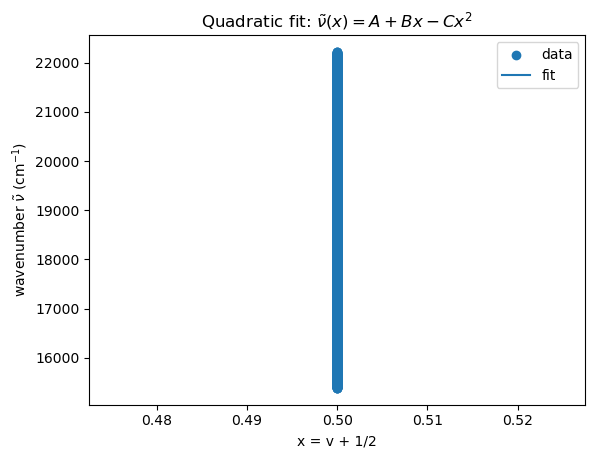

In [16]:
# Fit: numpy returns coefficients in descending order: [c_quad, b_lin, a_const]
coeffs = np.polyfit(x_vp, nu_cm1, deg=2)
c_quad, b_lin, a_const = coeffs
# Model: nu = A + B x - C x^2 => identify B = b_lin, C = -c_quad
A = a_const
B = b_lin
C = -c_quad
nu_e_prime = B
x_e_prime = C / B

print('Fit coefficients (nu = A + B x - C x^2):')
print(f'A = {A:.6f} cm^-1')
print(f'B = {B:.6f} cm^-1   (nu_e )')
print(f'C = {C:.6f} cm^-1   (nu_e * x_e)')
print(f'x_e = {x_e_prime:.6f}')

# Plot data and fit
x_fit = np.linspace(x_vp.min(), x_vp.max(), 400)
nu_fit = A + B * x_fit - C * x_fit**2
plt.figure()
plt.scatter(x_vp, nu_cm1, label='data')
plt.plot(x_fit, nu_fit, label='fit')
plt.xlabel(r'x = v + 1/2')
plt.ylabel(r'wavenumber $\tilde{\nu}$ (cm$^{-1}$)')
plt.title(r'Quadratic fit: $\tilde{\nu}(x) = A + Bx - Cx^2$')
plt.legend()
plt.show()

## Step 3 — Compute $v_\mathrm{max}'$, $\tilde D_e'$, and $\tilde D_0'$
Use $v_\mathrm{max}' = \tfrac{1}{2 x_e'} - \tfrac12$ (round to a nearby integer if needed). Compute term values with the fitted quadratic to get $\tilde D_e'$ and then subtract the zero-point energy for $\tilde D_0'$. Convert to joules for comparison.

In [ ]:
v_max_prime = 1.0 / (2.0 * x_e_prime) - 0.5
v_max_prime_int = int(round(v_max_prime))

def term_value_cm1(v: int) -> float:
    x = v + 0.5
    return A + B * x - C * x**2

nu_tilde_vmax = term_value_cm1(v_max_prime_int)
nu_tilde_v0 = term_value_cm1(0)
tilde_De_prime = nu_tilde_vmax   # within Morse model, peak of parabola
tilde_D0_prime = tilde_De_prime - nu_tilde_v0

# Convert to J
D_e_J = tilde_De_prime * 100.0 * h * c_light  # cm^-1 -> m^-1 then multiply by h c
D0_J = tilde_D0_prime * 100.0 * h * c_light

print(f"v_max' (float) = {v_max_prime:.3f}; rounded = {v_max_prime_int}")
print(f"tilde D_e' = {tilde_De_prime:.2f} cm^-1")
print(f"tilde D_0' = {tilde_D0_prime:.2f} cm^-1")
print(f"D_e' = {D_e_J:.3e} J")
print(f"D_0' = {D0_J:.3e} J")

## Step 4 — Force constant $k_f'$ and Morse width parameter $a'$
Use $k_f' = 4\pi^2 c^2 \mu\,\tilde{\nu}_e'^2$ (keep units consistent). Then $a' = \sqrt{k_f'/(2 D_e)}$ with $D_e$ in joules. Report $a'$ in \AA$^{-1}$.

In [ ]:
# Force constant (J/m^2); convert using nu_e in cm^-1 with c in cm/s, then to SI
k_f_prime = 4 * math.pi**2 * (c_light_cm**2) * mu * (nu_e_prime**2)  # units: kg*(cm/s)^2*(cm^-1)^2
k_f_prime_SI = k_f_prime * (1e-2)**2  # cm^2 to m^2

a_prime_inv_m = math.sqrt(k_f_prime_SI / (2 * D_e_J))
a_prime_inv_A = a_prime_inv_m * 1e-10

print(f"k_f' = {k_f_prime_SI:.3e} N/m")
print(f"a' = {a_prime_inv_A:.3f} 1/Å")

## Step 5 — Plot the Morse potential (excited state)
Plot $\tilde V(r) = \tilde D_e' [1 - e^{-a'(r-r_e')}}]^2$ in cm$^{-1}$ for a useful range around $r_e'$ (e.g., 2.5–4.0 \AA).

In [ ]:
r_e_prime_A = 2.97  # Angstrom (given)
r_vals_A = np.linspace(2.5, 4.0, 300)

# Convert a' back to m^-1 for the exponential
a_prime_m1 = a_prime_inv_A * 1e10

# Morse potential in cm^-1
tilde_V = tilde_De_prime * (1 - np.exp(-a_prime_m1 * (r_vals_A * 1e-10 - r_e_prime_A * 1e-10)))**2

plt.figure()
plt.plot(r_vals_A, tilde_V)
plt.axvline(r_e_prime_A, color='k', linestyle='--', linewidth=1, label=r'$r_e$')
plt.xlabel(r'internuclear distance $r$ (Å)')
plt.ylabel(r'$\tilde V(r)$ (cm$^{-1}$)')
plt.title('Morse potential (excited state)')
plt.legend()
plt.show()